In [82]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score
import joblib

# For geographical plots
import folium
from folium.plugins import HeatMap

In [83]:
# Load Dataset (update filename as needed)
df = pd.read_csv("Dataset_Final.csv")
print("Original dataset shape:", df.shape)
df.head(500)

Original dataset shape: (78425, 15)


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,9.3280,77.6247,318.0,1.1,1.0,2023-01-01,821,Aqua,MODIS,62,61.03,305.0,7.6,D,0
1,10.4797,77.9378,313.8,1.0,1.0,2023-01-01,822,Aqua,MODIS,58,61.03,299.4,4.3,D,0
2,13.2478,77.2639,314.7,1.0,1.0,2023-01-01,822,Aqua,MODIS,55,61.03,302.4,4.9,D,0
3,12.2994,78.4085,314.3,1.0,1.0,2023-01-01,822,Aqua,MODIS,58,61.03,301.9,4.8,D,0
4,14.1723,75.5024,338.4,1.2,1.1,2023-01-01,823,Aqua,MODIS,88,61.03,305.3,41.5,D,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,17.5890,75.4252,301.9,1.1,1.0,2023-01-04,1651,Terra,MODIS,45,61.03,289.6,6.2,N,0
496,17.5874,75.4150,300.5,1.1,1.0,2023-01-04,1651,Terra,MODIS,29,61.03,289.6,5.3,N,0
497,17.6594,75.4702,307.4,1.1,1.0,2023-01-04,1651,Terra,MODIS,71,61.03,289.9,9.5,N,0
498,17.7676,75.2187,300.8,1.1,1.1,2023-01-04,1651,Terra,MODIS,34,61.03,289.6,5.3,N,0


In [84]:
# Drop missing values & duplicates
df = df.dropna().drop_duplicates()
print("Dataset shape after cleaning:", df.shape)
df.head()


Dataset shape after cleaning: (78425, 15)


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,9.3280,77.6247,318.0,1.1,1.0,2023-01-01,821,Aqua,MODIS,62,61.03,305.0,7.6,D,0
1,10.4797,77.9378,313.8,1.0,1.0,2023-01-01,822,Aqua,MODIS,58,61.03,299.4,4.3,D,0
2,13.2478,77.2639,314.7,1.0,1.0,2023-01-01,822,Aqua,MODIS,55,61.03,302.4,4.9,D,0
3,12.2994,78.4085,314.3,1.0,1.0,2023-01-01,822,Aqua,MODIS,58,61.03,301.9,4.8,D,0
4,14.1723,75.5024,338.4,1.2,1.1,2023-01-01,823,Aqua,MODIS,88,61.03,305.3,41.5,D,0


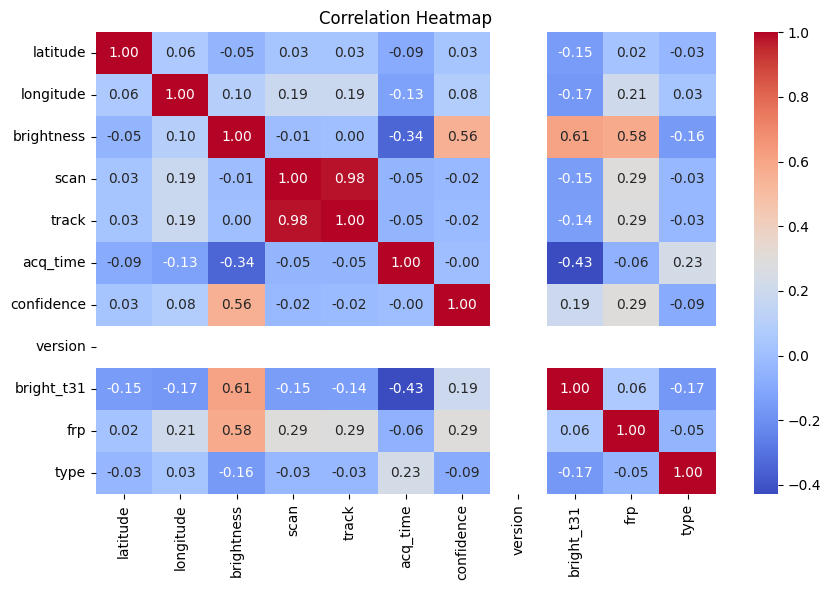

In [85]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()





In [86]:
# Time Series Analysis (assuming dataset has 'date' column)
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df_time = df.groupby(df['date'].dt.to_period("M")).size()

    plt.figure(figsize=(12,6))
    df_time.plot(kind="line", marker="o")
    plt.title(" Wildfires Over Time")
    plt.xlabel("Date")
    plt.ylabel("Number of Wildfires")
    plt.grid(True)
    plt.show()
else:
    print("No 'date' column found for time series analysis.")

No 'date' column found for time series analysis.


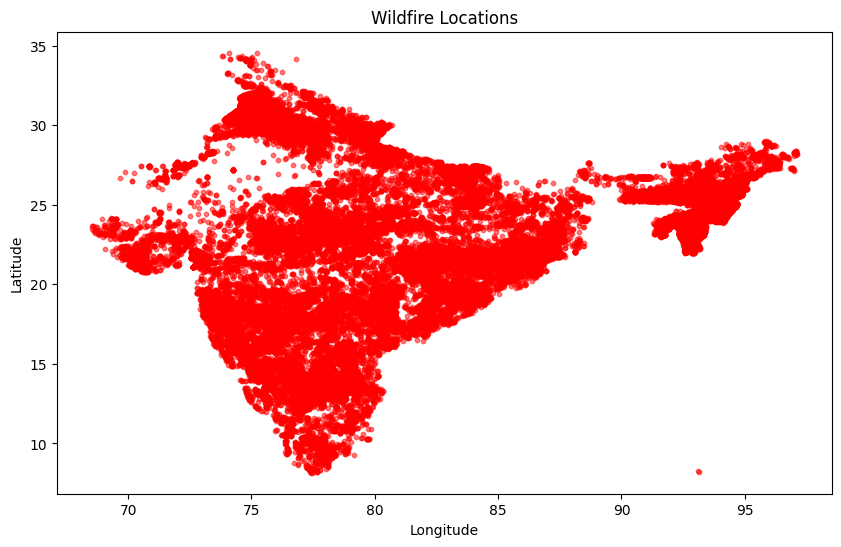

Interactive map saved as wildfire_map.html


In [87]:
# Geographical Scatter Plot (assuming 'latitude' & 'longitude' exist)
if 'latitude' in df.columns and 'longitude' in df.columns:
    plt.figure(figsize=(10,6))
    plt.scatter(df['longitude'], df['latitude'], alpha=0.5, c="red", s=10)
    plt.title("Wildfire Locations")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

    # Interactive HeatMap
    m = folium.Map(location=[df['latitude'].mean(), df['longitude'].mean()], zoom_start=5)
    heat_data = list(zip(df['latitude'], df['longitude']))
    HeatMap(heat_data).add_to(m)
    m.save("wildfire_map.html")
    print("Interactive map saved as wildfire_map.html")
else:
    print("No latitude/longitude columns found for geographical analysis.")
    

In [88]:
print(df.columns)

Index(['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date',
       'acq_time', 'satellite', 'instrument', 'confidence', 'version',
       'bright_t31', 'frp', 'daynight', 'type'],
      dtype='object')


In [89]:
# Create binary target column: fire (1) if confidence > 50, else no fire (0)
df['fire'] = (df['confidence'] > 50).astype(int)

target_col = "fire"

In [90]:
X = df.drop(columns=[target_col])
y = df[target_col]

Brightness Prediction MSE: 4.172833964488358
R² Score: 0.9748652060317712


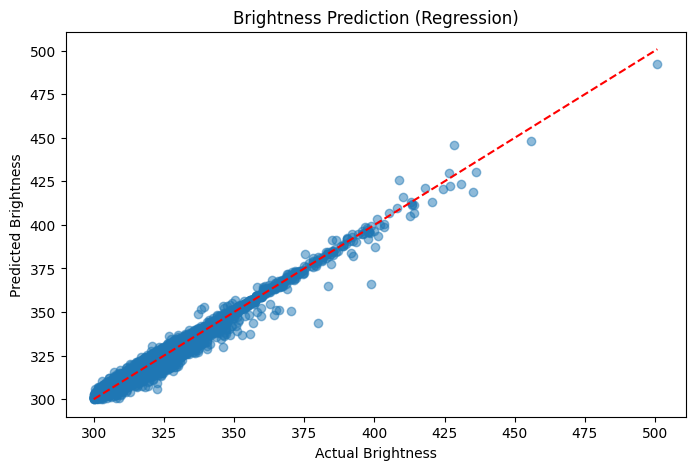

Brightness model saved as wildfire_brightness_model.pkl


In [91]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import matplotlib.pyplot as plt

# Target column
target_reg = "brightness"

# Features: drop only target column
X_reg = df.drop(columns=[target_reg])
y_reg = df[target_reg]

# Keep only numeric features
X_reg_num = X_reg.select_dtypes(include=[float, int])

# Scale numeric features
scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg_num)

# Train/test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42
)

# Train RandomForest Regressor
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train_r, y_train_r)

# Predict on test set
y_pred_r = reg.predict(X_test_r)

# Evaluate
mse = mean_squared_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)
print("Brightness Prediction MSE:", mse)
print("R² Score:", r2)

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_test_r, y_pred_r, alpha=0.5)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], "r--")
plt.xlabel("Actual Brightness")
plt.ylabel("Predicted Brightness")
plt.title("Brightness Prediction (Regression)")
plt.show()

# Save model + scaler + feature names for deployment
joblib.dump((reg, scaler_reg, X_reg_num.columns.tolist()), "wildfire_brightness_model.pkl")
print("Brightness model saved as wildfire_brightness_model.pkl")

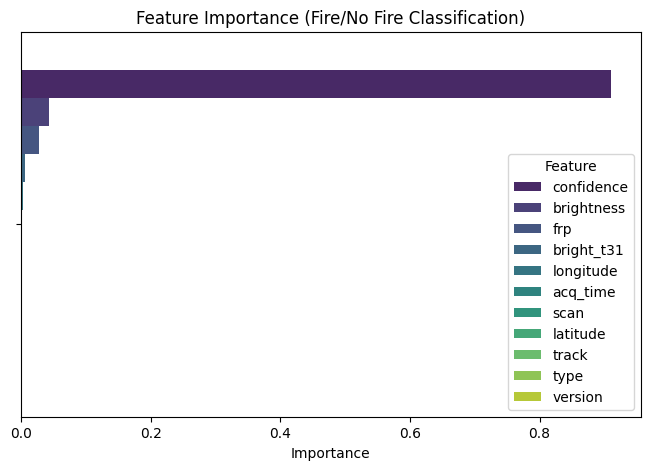

In [92]:
# Feature importance from RandomForest
import pandas as pd

feature_names = X.select_dtypes(include=[float, int]).columns  # only numeric features
importances = clf.feature_importances_

feat_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", hue="Feature", data=feat_imp, palette="viridis")
plt.title("Feature Importance (Fire/No Fire Classification)")
plt.show()

In [93]:
import joblib

# Save classifier and scaler for later use
joblib.dump((clf, scaler, feature_names.tolist()), "wildfire_classifier.pkl")
print("Model saved as wildfire_classifier.pkl")

Model saved as wildfire_classifier.pkl


In [94]:
# Example: take 1 new row from dataset (without fire column)
new_data = df.drop(columns=['fire']).iloc[[0]]  

# Scale features
new_data_scaled = scaler.transform(new_data[feature_names])

# Predict
prediction = clf.predict(new_data_scaled)
print(" Prediction for new data:", "FIRE" if prediction[0] == 1 else "NO FIRE")

 Prediction for new data: FIRE


In [95]:
obj = joblib.load("wildfire_brightness_model.pkl")
print(type(obj))
print(obj)

<class 'tuple'>
(RandomForestRegressor(random_state=42), StandardScaler(), ['latitude', 'longitude', 'scan', 'track', 'acq_time', 'confidence', 'version', 'bright_t31', 'frp', 'type', 'fire'])


In [96]:
import joblib
import pandas as pd

# Load regression model, scaler, and features
reg, scaler_reg, features_reg = joblib.load("wildfire_brightness_model.pkl")
print(" Brightness prediction model loaded successfully!")

 Brightness prediction model loaded successfully!
